# PCA — Country Data (Help International)
**Lead University · Minería de Datos · Tarea 3**

Análisis de Componentes Principales sobre indicadores de desarrollo.
Objetivo: segmentar países para priorización de ayuda humanitaria e identificar contrastes socioeconómicos.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scripts import PCAAnalysis

sns.set(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
print('Librerías cargadas.')

Librerías cargadas.


In [3]:
df = pd.read_csv('datos/Country-data.csv')
print(f'Registros: {df.shape[0]} | Variables: {df.shape[1]}')
print(f'Columnas: {df.columns.tolist()}')
df.head()

Registros: 167 | Variables: 10
Columnas: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


---
## Limpieza y selección de variables

Se usan todas las variables numéricas de indicadores de desarrollo. La columna `country` se conserva como índice para etiquetar países en los gráficos.

In [4]:
num_cols = ['child_mort', 'exports', 'health', 'imports', 'income',
            'inflation', 'life_expec', 'total_fer', 'gdpp']

df_clean = df.dropna(subset=num_cols).copy()
df_clean = df_clean.set_index('country')
print(f'Registros tras limpieza: {len(df_clean)}')
print()
print(df_clean[num_cols].describe().round(2))

Registros tras limpieza: 167

       child_mort  exports  health  imports     income  inflation  life_expec  \
count      167.00   167.00  167.00   167.00     167.00     167.00      167.00   
mean        38.27    41.11    6.82    46.89   17144.69       7.78       70.56   
std         40.33    27.41    2.75    24.21   19278.07      10.57        8.89   
min          2.60     0.11    1.81     0.07     609.00      -4.21       32.10   
25%          8.25    23.80    4.92    30.20    3355.00       1.81       65.30   
50%         19.30    35.00    6.32    43.30    9960.00       5.39       73.10   
75%         62.10    51.35    8.60    58.75   22800.00      10.75       76.80   
max        208.00   200.00   17.90   174.00  125000.00     104.00       82.80   

       total_fer       gdpp  
count     167.00     167.00  
mean        2.95   12964.16  
std         1.51   18328.70  
min         1.15     231.00  
25%         1.80    1330.00  
50%         2.41    4660.00  
75%         3.88   14050.00  


---
## Ajuste del PCA

In [5]:
pca = PCAAnalysis(n_components=5)
pca.ajustar(df_clean, columnas_pca=num_cols)

print('Varianza explicada por componente:')
for i, v in enumerate(pca.varianza_explicada):
    acum = pca.varianza_acumulada[i]
    print(f'  PC{i+1}: {v:.2f} % (acumulada: {acum:.2f} %)')
print()
print(f'Componentes necesarios para >= 80%: {pca.n_componentes_80()}')

Varianza explicada por componente:
  PC1: 45.95 % (acumulada: 45.95 %)
  PC2: 17.18 % (acumulada: 63.13 %)
  PC3: 13.00 % (acumulada: 76.14 %)
  PC4: 11.05 % (acumulada: 87.19 %)
  PC5: 7.34 % (acumulada: 94.53 %)

Componentes necesarios para >= 80%: 4


---
## Visualizaciones obligatorias

### Scree Plot

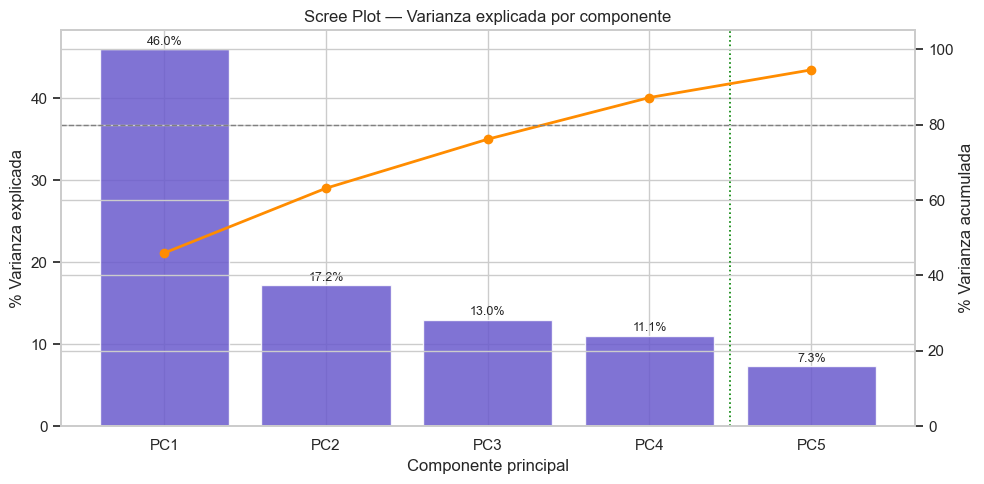

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
pca.scree_plot(ax=ax)
plt.tight_layout()
plt.show()

**Interpretación:**

- El primer componente captura casi la mitad de la varianza, representando el eje de desarrollo (riqueza vs pobreza).
- Se necesitan 4 componentes para alcanzar el 80 %, reflejando que los indicadores capturan múltiples dimensiones del desarrollo (económica, demográfica, comercial).

### Círculo de correlación

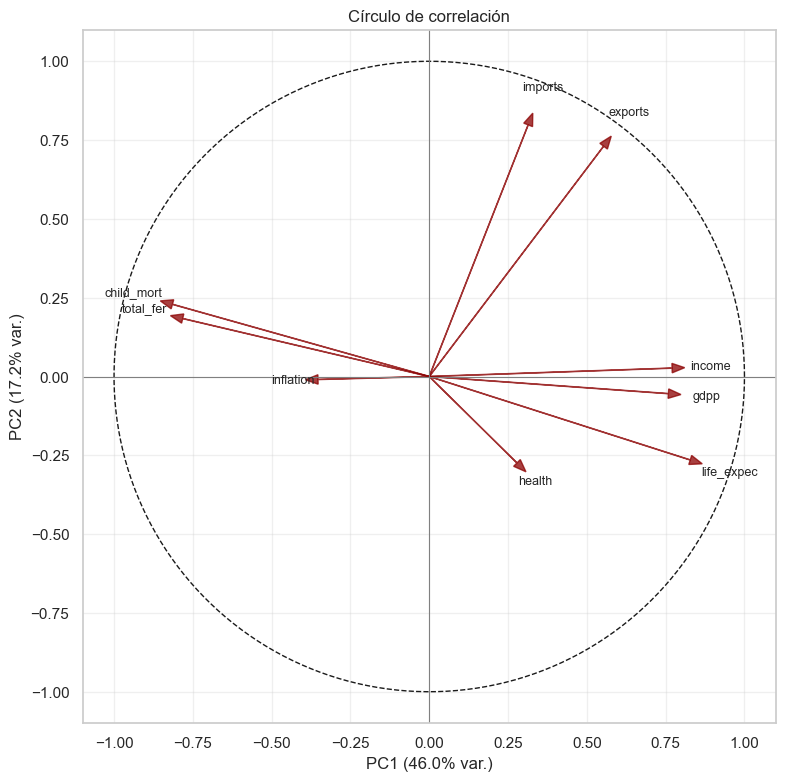

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))
pca.circulo_correlacion(ax=ax)
plt.tight_layout()
plt.show()

**Interpretación:**

- `child_mort` y `total_fer` (mortalidad infantil y fertilidad) se oponen diametralmente a `gdpp`, `income` y `life_expec`, formando el eje de desarrollo humano en PC1.
- `imports` apunta casi verticalmente (PC2 alto, bajo PC1), representando apertura comercial de forma ortogonal al desarrollo. `exports` apunta en diagonal (arriba-derecha), contribuyendo tanto a PC2 como parcialmente a PC1 — los países más desarrollados también tienden a exportar más.
- `inflation` y `health` tienen correlaciones bajas con PC1-PC2 (cos² sumado < 0.25), aportando principalmente a componentes posteriores (PC3).
- La oposición `child_mort` vs `gdpp` confirma: países con alto PIB per cápita tienen baja mortalidad infantil.

### Plano principal (PC1 vs PC2)

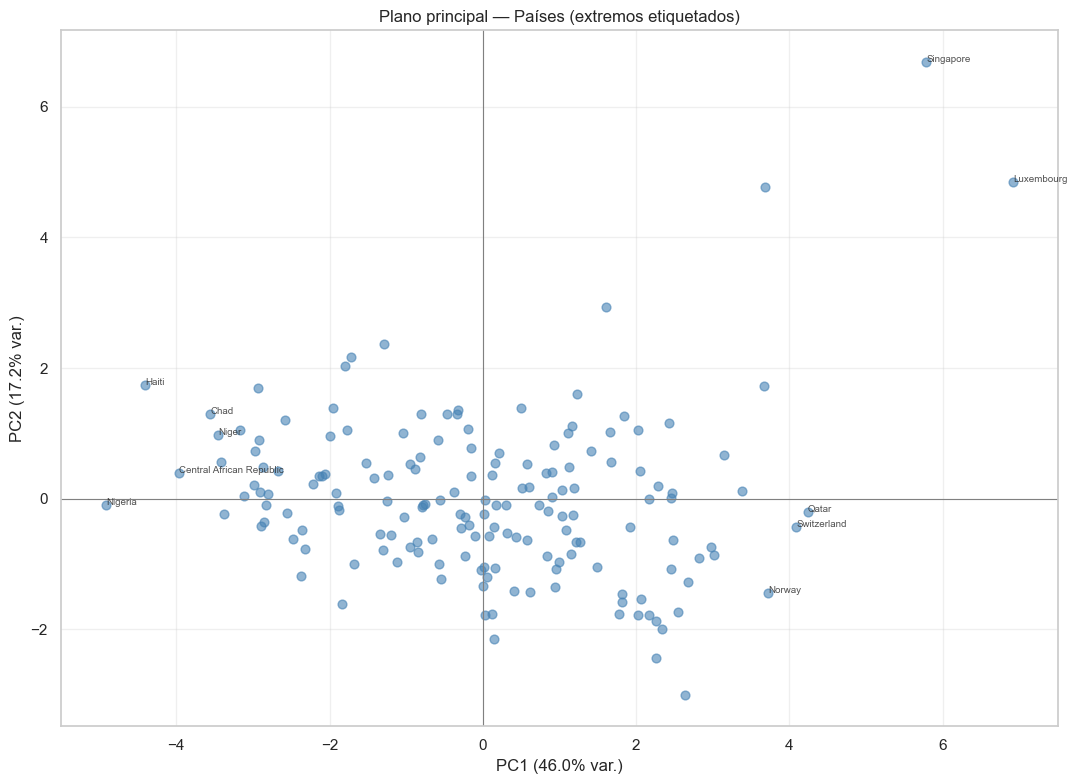

In [8]:
fig, ax = plt.subplots(figsize=(11, 8))
pca.plano_principal(ax=ax)

# Etiquetar países extremos
coords = pca.row_coords
extremos_pc1 = coords.nlargest(5, 'PC1').index.tolist() + coords.nsmallest(5, 'PC1').index.tolist()
for idx in extremos_pc1:
    ax.annotate(idx, (coords.loc[idx, 'PC1'], coords.loc[idx, 'PC2']),
                fontsize=7, alpha=0.8)

ax.set_title('Plano principal — Países (extremos etiquetados)')
plt.tight_layout()
plt.show()

**Interpretación:**

- Los países desarrollados (alto ingreso, alta esperanza de vida) se ubican en un extremo del PC1; los subdesarrollados en el opuesto.
- En el extremo negativo del PC1 se encuentran países con alta mortalidad infantil (Chad, Sierra Leona, etc.) — candidatos prioritarios para ayuda humanitaria.
- El PC2 separa economías exportadoras/importadoras (ej. países petroleros) del resto.

### Biplot

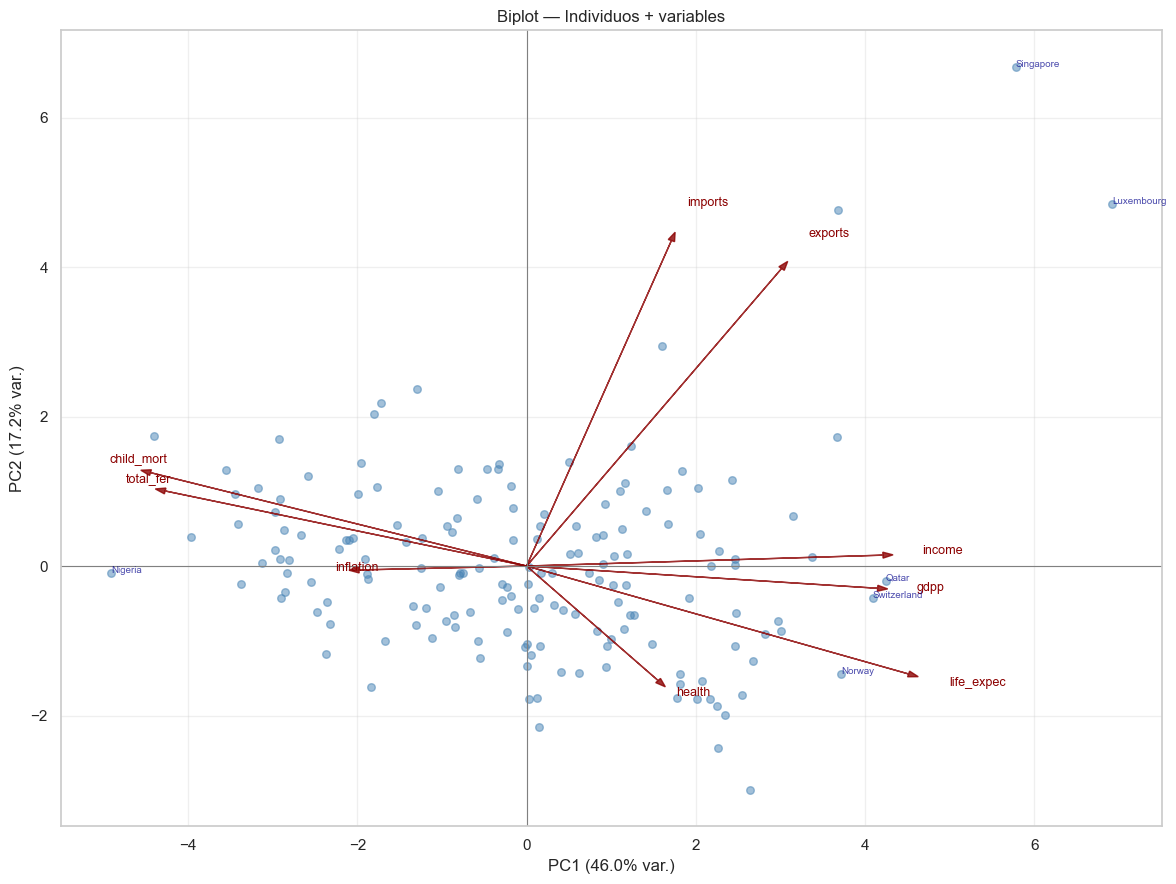

In [9]:
fig, ax = plt.subplots(figsize=(12, 9))
pca.biplot(ax=ax)

# Etiquetar algunos extremos
for idx in extremos_pc1[:6]:
    ax.annotate(idx, (coords.loc[idx, 'PC1'], coords.loc[idx, 'PC2']),
                fontsize=7, alpha=0.7, color='darkblue')

ax.set_title('Biplot — Individuos + variables')
plt.tight_layout()
plt.show()

**Interpretación:**

- El biplot confirma que los países con alta mortalidad infantil se alinean con los vectores de `child_mort` y `total_fer`.
- Los países desarrollados apuntan hacia `gdpp`, `income` y `life_expec`.
- La segmentación natural sugiere al menos 3 grupos: desarrollados, en desarrollo y subdesarrollados — base para priorizar intervenciones de Help International.

---
## Tablas de contribuciones y correlaciones

In [10]:
print('Contribución de cada variable por componente (%):')
print(pca.contribuciones())
print()
print('Cos² de variables (calidad de representación):')
print(pca.cos2_variables())

Contribución de cada variable por componente (%):
              PC1    PC2    PC3    PC4    PC5
variable                                     
child_mort  17.60   3.72   0.09  13.74   2.86
exports      8.06  37.60   2.10   0.00   0.33
health       2.28   5.91  35.60  21.33  26.83
imports      2.61  45.13   9.00   0.52   6.52
income      15.88   0.05   9.09  15.38   6.11
inflation    3.73   0.01  41.28   2.26  51.10
life_expec  18.13   4.96   1.30   4.15   1.17
total_fer   16.30   2.41   0.04  14.31   1.83
gdpp        15.42   0.21   1.51  28.30   3.25

Cos² de variables (calidad de representación):
               PC1     PC2     PC3     PC4     PC5
variable                                          
child_mort  0.7279  0.0575  0.0010  0.1367  0.0189
exports     0.3333  0.5814  0.0245  0.0000  0.0022
health      0.0941  0.0914  0.4166  0.2122  0.1773
imports     0.1078  0.6979  0.1053  0.0051  0.0431
income      0.6566  0.0008  0.1064  0.1530  0.0404
inflation   0.1543  0.0001  0.4832  0.0

---
## Interpretación técnica

**Contraste socioeconómico:** Las variables `child_mort` y `gdpp` se oponen diametralmente en el círculo de correlación (correlaciones de signo opuesto en PC1: child_mort ≈ -0.85, gdpp ≈ +0.80). Esto confirma que el PC1 captura el gradiente de desarrollo humano.

Los países en el extremo de la mortalidad infantil alta (visibles en el biplot como los más negativos en PC1) son los candidatos prioritarios para ayuda humanitaria: combinan alta fertilidad, baja esperanza de vida y bajo PIB per cápita.